In [126]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report, matthews_corrcoef, roc_curve, roc_auc_score,
							accuracy_score, precision_score, recall_score, f1_score)

In [103]:
import random
# setting seed so the results are consistently reproducible
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [104]:
train=pd.read_csv("data/preprocessedTrain.csv")
test=pd.read_csv("data/preprocessedTest.csv")

In [105]:
# To fill nulls 

train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 

In [106]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 84)
Test shape: (24624, 84)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

In [107]:
def to_binary_label(y):
    # 0 = benign, 1 = malicious
    benign = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
    return [0 if val in benign else 1 for val in y]

y_train = to_binary_label(train["Attack_type"])
y_test = to_binary_label(test["Attack_type"])
y_train=np.array(y_train)
y_test = np.array(y_test)

# TEST
X_train = train.drop("Attack_type", axis=1)
X_test = test.drop("Attack_type", axis=1).values

### Train-Val Split

In [109]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
X_val = X_val.values

In [ ]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Validation
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32) 

In [ ]:
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
X_val_tensor = X_val_tensor.unsqueeze(1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)

torch.Size([78794, 1, 83])


In [114]:
class BinaryAttnCNN(nn.Module):
    def __init__(self, input_length=83, dropout_rate=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout1d(dropout_rate)

         # Self-attention mechanism
        self.attn_embed_dim = 32
        self.num_heads = 8
        self.attn = nn.MultiheadAttention(embed_dim=self.attn_embed_dim, num_heads=self.num_heads, batch_first=True)

        self.fc1 = nn.Linear(32 * (input_length // 2), 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))

        # Apply self-attention
        B, C, L = x.shape  # Batch, Channels, Length
        x = x.permute(0, 2, 1)  # (B, L, C) for attention
        attn_out, _ = self.attn(x, x, x)
        x = attn_out + x  # Residual connection
        x = x.permute(0, 2, 1).contiguous().view(B, -1)  # Back to (B, C*L)
        

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x
    
# Check if gpu is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [115]:
model = BinaryAttnCNN()  
model = model.to(device) 

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [118]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    print("start epoch")
    for batch, (X_batch, y_batch) in enumerate(train_loader):
        # Move data to GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        running_loss += loss.item()
        
        if (batch+1) % 500 == 0:
            print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
            running_loss = 0.0

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

start epoch
[1, 500] loss: 0.1940
[1, 1000] loss: 0.1886
Epoch [1/20], Loss: 0.1909
start epoch
[2, 500] loss: 0.1834
[2, 1000] loss: 0.1774
Epoch [2/20], Loss: 0.1804
start epoch
[3, 500] loss: 0.1749
[3, 1000] loss: 0.1709
Epoch [3/20], Loss: 0.1721
start epoch
[4, 500] loss: 0.1651
[4, 1000] loss: 0.1617
Epoch [4/20], Loss: 0.1644
start epoch
[5, 500] loss: 0.1589
[5, 1000] loss: 0.1594
Epoch [5/20], Loss: 0.1585
start epoch
[6, 500] loss: 0.1569
[6, 1000] loss: 0.1505
Epoch [6/20], Loss: 0.1531
start epoch
[7, 500] loss: 0.1495
[7, 1000] loss: 0.1483
Epoch [7/20], Loss: 0.1489
start epoch
[8, 500] loss: 0.1496
[8, 1000] loss: 0.1424
Epoch [8/20], Loss: 0.1455
start epoch
[9, 500] loss: 0.1407
[9, 1000] loss: 0.1414
Epoch [9/20], Loss: 0.1404
start epoch
[10, 500] loss: 0.1349
[10, 1000] loss: 0.1377
Epoch [10/20], Loss: 0.1364
start epoch
[11, 500] loss: 0.1337
[11, 1000] loss: 0.1352
Epoch [11/20], Loss: 0.1356
start epoch
[12, 500] loss: 0.1327
[12, 1000] loss: 0.1317
Epoch [12/2

In [ ]:
model.eval()
all_preds = []
all_labels = []
all_probs = []  

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)               
        preds = (probs > 0.5).int()                 

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())


print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))

[[ 2301   201]
 [   42 22080]]
              precision    recall  f1-score   support

      Benign       0.98      0.92      0.95      2502
   Malicious       0.99      1.00      0.99     22122

    accuracy                           0.99     24624
   macro avg       0.99      0.96      0.97     24624
weighted avg       0.99      0.99      0.99     24624



---

## Test

[[ 1821   180]
 [   28 17670]]
ROC-AUC: 0.9984566706363172


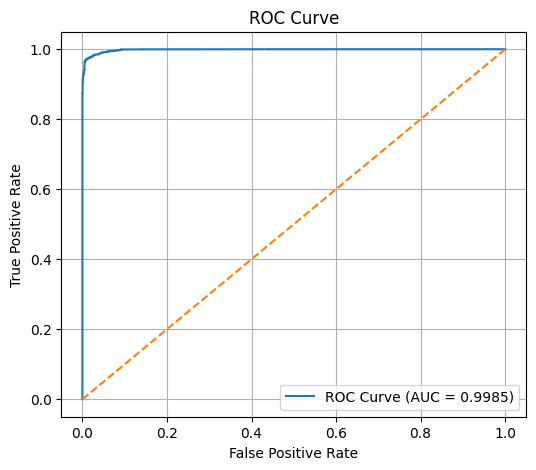

Success


In [122]:
model.eval()
all_preds = []
all_labels = []
all_probs = []  

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)               
        preds = (probs > 0.5).int()                 

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))

report = classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"], output_dict=True)

roc_auc = roc_auc_score(all_labels, all_probs)
print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")         # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.savefig("classification_reports/roc_curve_cnn_binary_attn.png", dpi=300)
plt.show()
plt.close()

report["ROC_AUC"] = {"Score": roc_auc}
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_reports/evaluation_metrics_cnn_binary_attn_roc.csv", index=True)
print("Success")


In [123]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
precw = precision_score(all_labels, all_preds, )
recw = recall_score(all_labels, all_preds, )
f1w = f1_score(all_labels, all_preds, )
mcc = matthews_corrcoef(all_labels, all_preds)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print(f"Weighted Precision: {precw:.4f}")
print(f"Weighted Recall: {recw:.4f}")
print(f"Weighted F1 Score: {f1w:.4f}")
print(f"MCC Score: {mcc:.4f}")


Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.91      0.95      2001
   Malicious       0.99      1.00      0.99     17698

    accuracy                           0.99     19699
   macro avg       0.99      0.95      0.97     19699
weighted avg       0.99      0.99      0.99     19699


Overall Metrics:
Accuracy: 0.9894
Macro Precision: 0.9874
Macro Recall: 0.9542
Macro F1 Score: 0.9701
Weighted Precision: 0.9899
Weighted Recall: 0.9984
Weighted F1 Score: 0.9941
MCC Score: 0.9410


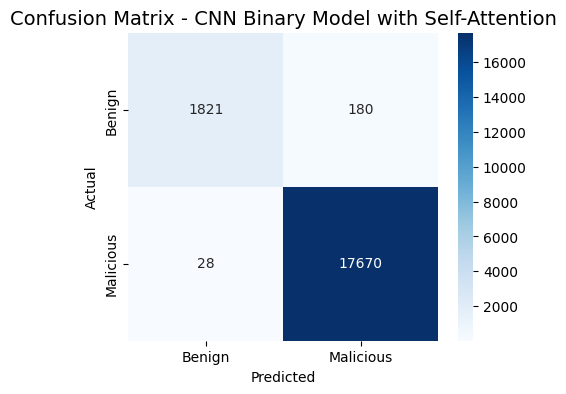

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Binary Model with Self-Attention",fontsize=14)
plt.savefig("confusionmatrices/1dcnn_attn_binary.png", dpi=600, bbox_inches='tight')
plt.show()

In [125]:
torch.save(model.state_dict(), "1dcnn_binary_attn.pth")
print("Model saved to 1dcnn_binary_attn.pth")

Model saved to 1dcnn_binary_attn.pth
